In [1]:
!pip install --upgrade statsmodels

In [606]:
import scipy
import statsmodels.formula.api as smf
import yfinance as yf
import numpy as np
import pandas as pd
import talib
from datetime import datetime
import matplotlib.pyplot as plt
import vectorbt as vbt

In [607]:
pd.set_option('display.max_columns', None)

In [609]:
ndf = pd.read_csv('./NVDA.csv', parse_dates=['Date'], index_col='Date')
ndf.tail()

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,0,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,0,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,0,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.276875,2.270004,1.164284,198.049025,200.477085,204.176294,204.738312,188.610223,divergence,True,True,False,False,False,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.849991,5.520004
2026-07-01,NVDA,197.580002,199.850006,193.449997,196.199997,146147600,Bullish,0,0,0,21.562545,2.270004,35.468766,2.750000,42.968689,3.637671,43.320561,-3.889999,-1.944125,197.892684,199.950343,203.548076,204.457594,188.699475,divergence,True,False,False,False,False,0,1,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.380005,6.400009
2026-07-02,NVDA,194.830002,200.059998,192.350006,197.139999,142068700,Bearish,0,0,0,29.961091,2.919998,37.872911,2.479996,32.165998,2.337662,41.219174,-0.440002,-0.222696,196.871790,199.019372,202.717783,204.080041,188.760475,divergence,True,True,False,False,False,0,0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.309998,7.709991


In [610]:
ndf = ndf.rename(columns = {'5_day_return': 'Day5_return', 
                            '10_day_return': 'Day10_return', 
                            '15_day_return': 'Day15_return',
                            '22_day_return': 'Day22_return', 
                            '6_month_return': 'Month6_return',
                            '5_year_return': 'Year5_return'}
                )

ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,Doji,0,0,0,0.000000,0.003595,31.915002,0.007669,68.084998,inf,NaN,NaN,NaN,0.482423,0.482423,0.482423,0.482423,0.482423,divergence,True,True,True,True,True,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0.000000,0.011264
2015-01-05,NVDA,0.474275,0.483861,0.472118,0.482423,197952000,Bearish,0,0,0,69.387800,0.001438,12.244977,0.002157,18.367223,0.441176,NaN,-1.677890e-08,-0.000003,0.479707,0.480941,0.481647,0.482103,0.482342,Bearish,True,True,True,True,True,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0.008148,0.011743
2015-01-06,NVDA,0.459896,0.475473,0.459416,0.474994,197764000,Bearish,0,0,0,94.029920,0.000479,2.985040,0.000479,2.985040,0.063491,NaN,7.190040e-04,0.151601,0.473103,0.477115,0.479575,0.481233,0.482119,Bearish,True,False,False,False,False,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0.015098,0.016057
2015-01-07,NVDA,0.458697,0.467325,0.457259,0.463251,321808000,Bearish,0,0,0,45.237879,0.004074,40.476326,0.001438,14.285795,1.210537,NaN,3.355113e-03,0.729538,0.468301,0.473766,0.477587,0.480349,0.481886,Bearish,False,False,False,False,False,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0.004553,0.010065
2015-01-08,NVDA,0.475952,0.478828,0.463730,0.463970,283780000,Bullish,0,0,0,79.364899,0.002876,19.047727,0.000240,1.587374,0.260003,NaN,5.272450e-03,1.149440,0.470852,0.474164,0.477431,0.480176,0.481826,Bearish,True,True,True,False,False,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0.011983,0.015098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,0,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010e+00,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,0,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007e+00,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,0,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.276875,2.270004e+00,1.164284,198.049025,200.477085,204.176294,204.738312,188.610223,divergence,True,True,False,False,False,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.849991,5.520004


In [611]:


# Put all EMA's in a list 

EMAs =['5_EMA', '10_EMA', '20_EMA', '50_EMA', '200_EMA'] 


for ema in EMAs:

    #Start for loop and set column variable using f string place holders 
    
    Candle_Distance = f"{ema}_candle_distance"
    Candle_Location = f"{ema}_candle_location"

    # Set list of conditions so we can know when candle low is above the EMA or the candle High is below the EMA 
    conditions = [
    ndf['Low'] > ndf[ema],
    ndf['High'] < ndf[ema]
    ]
    # Create a list of choices based on conditions 
    positions = [
        'Above',
        'Below'
    ]
    # Use np.select to create the columns for each EMA with the answer values and default value if neither condition is met 
    ndf[Candle_Location]= np.select(
        conditions, 
        positions, 
        default='touched'
    )

    distances =[
        ndf['Low'] - ndf[ema],
        ndf['High'] - ndf[ema]
    ]

    ndf[Candle_Distance]= np.select(
        conditions,
        distances, 
        default=0.0
    )


ndf
    

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,Doji,0,0,0,0.000000,0.003595,31.915002,0.007669,68.084998,inf,NaN,NaN,NaN,0.482423,0.482423,0.482423,0.482423,0.482423,divergence,True,True,True,True,True,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0.000000,0.011264,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000
2015-01-05,NVDA,0.474275,0.483861,0.472118,0.482423,197952000,Bearish,0,0,0,69.387800,0.001438,12.244977,0.002157,18.367223,0.441176,NaN,-1.677890e-08,-0.000003,0.479707,0.480941,0.481647,0.482103,0.482342,Bearish,True,True,True,True,True,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0.008148,0.011743,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000
2015-01-06,NVDA,0.459896,0.475473,0.459416,0.474994,197764000,Bearish,0,0,0,94.029920,0.000479,2.985040,0.000479,2.985040,0.063491,NaN,7.190040e-04,0.151601,0.473103,0.477115,0.479575,0.481233,0.482119,Bearish,True,False,False,False,False,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0.015098,0.016057,touched,0.000000,Below,-0.001642,Below,-0.004102,Below,-0.005760,Below,-0.006646
2015-01-07,NVDA,0.458697,0.467325,0.457259,0.463251,321808000,Bearish,0,0,0,45.237879,0.004074,40.476326,0.001438,14.285795,1.210537,NaN,3.355113e-03,0.729538,0.468301,0.473766,0.477587,0.480349,0.481886,Bearish,False,False,False,False,False,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0.004553,0.010065,Below,-0.000976,Below,-0.006441,Below,-0.010262,Below,-0.013024,Below,-0.014561
2015-01-08,NVDA,0.475952,0.478828,0.463730,0.463970,283780000,Bullish,0,0,0,79.364899,0.002876,19.047727,0.000240,1.587374,0.260003,NaN,5.272450e-03,1.149440,0.470852,0.474164,0.477431,0.480176,0.481826,Bearish,True,True,True,False,False,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0.011983,0.015098,touched,0.000000,touched,0.000000,touched,0.000000,Below,-0.001348,Below,-0.002998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,0,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010e+00,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,Below,-2.507805,Below,-6.256014,Below,-10.070789,Below,-9.784486,Above,2.790229
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,0,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007e+00,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,Below,-0.848547,Below,-4.383113,Below,-8.426438,Below,-8.748046,Above,1.305154
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,0,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936

In [618]:
ndf["positive_22_day_return"] = ndf["Day22_return"] > 0
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance,positive_22_day_return
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,Doji,0,0,0,0.000000,0.003595,31.915002,0.007669,68.084998,inf,NaN,NaN,NaN,0.482423,0.482423,0.482423,0.482423,0.482423,divergence,True,True,True,True,True,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0.000000,0.011264,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,True
2015-01-05,NVDA,0.474275,0.483861,0.472118,0.482423,197952000,Bearish,0,0,0,69.387800,0.001438,12.244977,0.002157,18.367223,0.441176,NaN,-1.677890e-08,-0.000003,0.479707,0.480941,0.481647,0.482103,0.482342,Bearish,True,True,True,True,True,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0.008148,0.011743,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,True
2015-01-06,NVDA,0.459896,0.475473,0.459416,0.474994,197764000,Bearish,0,0,0,94.029920,0.000479,2.985040,0.000479,2.985040,0.063491,NaN,7.190040e-04,0.151601,0.473103,0.477115,0.479575,0.481233,0.482119,Bearish,True,False,False,False,False,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0.015098,0.016057,touched,0.000000,Below,-0.001642,Below,-0.004102,Below,-0.005760,Below,-0.006646,True
2015-01-07,NVDA,0.458697,0.467325,0.457259,0.463251,321808000,Bearish,0,0,0,45.237879,0.004074,40.476326,0.001438,14.285795,1.210537,NaN,3.355113e-03,0.729538,0.468301,0.473766,0.477587,0.480349,0.481886,Bearish,False,False,False,False,False,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0.004553,0.010065,Below,-0.000976,Below,-0.006441,Below,-0.010262,Below,-0.013024,Below,-0.014561,True
2015-01-08,NVDA,0.475952,0.478828,0.463730,0.463970,283780000,Bullish,0,0,0,79.364899,0.002876,19.047727,0.000240,1.587374,0.260003,NaN,5.272450e-03,1.149440,0.470852,0.474164,0.477431,0.480176,0.481826,Bearish,True,True,True,False,False,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0.011983,0.015098,touched,0.000000,touched,0.000000,touched,0.000000,Below,-0.001348,Below,-0.002998,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,0,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010e+00,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,Below,-2.507805,Below,-6.256014,Below,-10.070789,Below,-9.784486,Above,2.790229,False
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,0,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007e+00,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,Below,-0.848547,Below,-4.383113,Below,-8.426438,Below,-8.748046,Above,1.305154,False
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,B

In [619]:
ndf.index.dtype

dtype('<M8[ns]')

In [620]:
import calendar

In [621]:
from numba import njit
from vectorbt.signals.factory import SignalFactory

In [622]:
import vectorbt as vbt #import backtester Vector BT

In [625]:
ema_10_fix_tbl =ndf[
    (ndf['10EMA_days_since_touch'] >= 2) &
    (ndf['10EMA_days_since_touch'].shift(1) < 2)
]
ema_10_fix_above = ema_10_fix_tbl[ema_10_fix_tbl['10_EMA_candle_location'] == 'Above']

ema_10_fix_above[ema_10_fix_above["Day22_return"] > 0]

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance,positive_22_day_return
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-23,NVDA,0.496323,0.497282,0.491290,0.495364,120416000,Bullish,0,0,0,16.000687,0.000959,15.999733,0.004074,67.999580,5.249732,58.529462,0.000479,0.096875,0.488472,0.483215,0.480476,0.480397,0.481669,divergence,False,False,False,False,False,1,2,2,-7.291167,-1.496886,7.725770,7.316531,-4.312100,39.651714,1148.527225,0.000959,0.005991,Above,0.002818,Above,0.008075,Above,0.010814,Above,0.010894,Above,0.009621,True
2015-02-05,NVDA,0.491051,0.491290,0.483142,0.483621,140448000,Bullish,1,0,0,91.177089,0.000240,2.940970,0.000479,5.881940,0.096767,55.378868,0.000479,0.099164,0.481846,0.479400,0.478619,0.479291,0.481224,divergence,False,False,False,False,False,2,2,2,8.833574,9.028817,8.076891,12.682072,1.292657,39.960433,1096.882063,0.007429,0.008148,Above,0.001296,Above,0.003742,Above,0.004523,Above,0.003851,Above,0.001918,True
2015-07-31,NVDA,0.482172,0.486039,0.479272,0.485797,218340000,Bearish,1,0,0,53.571611,0.000242,3.571185,0.002900,42.857204,0.866660,47.567366,0.001934,0.399602,0.479957,0.478776,0.482075,0.495217,0.502912,divergence,True,False,True,False,False,0,2,0,15.187958,17.994942,8.071833,8.524902,47.994629,190.314223,2051.400340,0.003625,0.006767,touched,0.000000,Above,0.000496,touched,0.000000,Below,-0.009178,Below,-0.016873,True
2015-08-05,NVDA,0.497398,0.504890,0.496431,0.504407,234628000,Bearish,1,0,0,82.856384,0.000483,5.714539,0.000967,11.429077,0.206908,57.455658,0.012084,2.454536,0.490064,0.485590,0.485066,0.495019,0.502631,divergence,False,False,False,False,True,2,2,2,15.257559,12.180430,6.422617,6.129865,38.125374,176.942088,2024.064916,0.007009,0.008459,Above,0.006367,Above,0.010841,Above,0.011366,Above,0.001413,touched,0.000000,True
2015-08-31,NVDA,0.545605,0.552887,0.543421,0.549003,219352000,Bearish,0,0,0,35.897859,0.003883,41.025688,0.002184,23.076453,1.785681,56.231007,-0.002670,-0.483926,0.540216,0.537706,0.532161,0.520084,0.509633,Bullish,False,False,False,False,False,3,2,3,0.889636,2.046235,1.823801,7.517812,46.771003,179.046488,2226.078390,0.003398,0.009466,Above,0.003205,Above,0.005715,Above,0.011260,Above,0.023337,Above,0.033788,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,NVDA,173.269241,174.487620,172.729966,173.379096,122316800,Doji,0,-100,-100,6.250054,1.108524,63.068413,0.539275,30.681532,14.999861,71.094311,-0.129831,-0.074827,171.728572,169.689047,164.705159,151.691457,131.062567,Bullish,False,False,False,False,False,2,2,59,0.126795,5.302582,4.005751,4.766563,8.179256,NaN,NaN,0.109854,1.757654,Above,1.001394,Above,3.040920,Above,8.024807,Above,21.038510,Above,41.667399,True
2025-09-30,NVDA,186.342331,187.111354,181.248821,181.848063,236981000,Bullish,-1,0,0,76.660853,0.769023,13.117596,0.599242,10.221551,0.304447,63.235947,0.229701,0.126474,181.442150,179.413223,177.724361,173.177011,148.097534,Bullish,True,False,False,False,False,0,2,2,-0.825376,-3.510558,-2.904915,8.741562,-6.517765,NaN,NaN,4.494268,5.862533,touched,0.000000,Above,1.835598,Above,3.524460,Above,8.071810,Above,33.151287,True
2025-

In [1116]:
ndf['talib_trendline'] = talib.HT_TRENDLINE(ndf['Close'])
ndf['trend_alert'] = np.where(ndf['Close'] > ndf['talib_trendline'], 1, -1)
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance,positive_22_day_return,talib_trend,talib_trendline,trend_alert
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,Doji,0,0,0,0.000000,0.003595,31.915002,0.007669,68.084998,inf,NaN,NaN,NaN,0.482423,0.482423,0.482423,0.482423,0.482423,divergence,True,True,True,True,True,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0.000000,0.011264,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,True,NaN,NaN,-1
2015-01-05,NVDA,0.474275,0.483861,0.472118,0.482423,197952000,Bearish,0,0,0,69.387800,0.001438,12.244977,0.002157,18.367223,0.441176,NaN,-1.677890e-08,-0.000003,0.479707,0.480941,0.481647,0.482103,0.482342,Bearish,True,True,True,True,True,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0.008148,0.011743,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,True,NaN,NaN,-1
2015-01-06,NVDA,0.459896,0.475473,0.459416,0.474994,197764000,Bearish,0,0,0,94.029920,0.000479,2.985040,0.000479,2.985040,0.063491,NaN,7.190040e-04,0.151601,0.473103,0.477115,0.479575,0.481233,0.482119,Bearish,True,False,False,False,False,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0.015098,0.016057,touched,0.000000,Below,-0.001642,Below,-0.004102,Below,-0.005760,Below,-0.006646,True,NaN,NaN,-1
2015-01-07,NVDA,0.458697,0.467325,0.457259,0.463251,321808000,Bearish,0,0,0,45.237879,0.004074,40.476326,0.001438,14.285795,1.210537,NaN,3.355113e-03,0.729538,0.468301,0.473766,0.477587,0.480349,0.481886,Bearish,False,False,False,False,False,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0.004553,0.010065,Below,-0.000976,Below,-0.006441,Below,-0.010262,Below,-0.013024,Below,-0.014561,True,NaN,NaN,-1
2015-01-08,NVDA,0.475952,0.478828,0.463730,0.463970,283780000,Bullish,0,0,0,79.364899,0.002876,19.047727,0.000240,1.587374,0.260003,NaN,5.272450e-03,1.149440,0.470852,0.474164,0.477431,0.480176,0.481826,Bearish,True,True,True,False,False,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0.011983,0.015098,touched,0.000000,touched,0.000000,touched,0.000000,Below,-0.001348,Below,-0.002998,True,NaN,NaN,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,0,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010e+00,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,Below,-2.507805,Below,-6.256014,Below,-10.070789,Below,-9.784486,Above,2.790229,False,206.623004,206.623004,-1
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,0,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007e+00,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,Below,-0.848547,Below

In [626]:


ema_10_fix =(
    (ndf['10EMA_days_since_touch'] >= 2) &
    (ndf['10EMA_days_since_touch'].shift(1) < 2)
)


In [628]:
entries_10 =(ema_10_fix &
    (ndf['10_EMA_candle_location'] == 'Above')
            ).fillna(False).astype(bool)


exits_10 = entries_10.vbt.signals.fshift(8)

In [629]:

EMA_10_hold = vbt.Portfolio.from_signals(
    close = ndf["Close"], 
    entries=entries_10,
    exits=exits_10,
    init_cash=3_000,
    fees=0.001,
    slippage=0.001,
    freq="1D"
)

EMA_10_hold.stats()

Start                               2015-01-02 00:00:00
End                                 2026-07-02 00:00:00
Period                               2891 days 00:00:00
Start Value                                      3000.0
End Value                                  31977.441935
Total Return [%]                             965.914731
Benchmark Return [%]                       40285.721834
Max Gross Exposure [%]                            100.0
Total Fees Paid                             3516.252461
Max Drawdown [%]                              41.453909
Max Drawdown Duration                 501 days 00:00:00
Total Trades                                        132
Total Closed Trades                                 132
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  62.878788
Best Trade [%]                                23.304975
Worst Trade [%]                              -19

In [630]:
Bullish_Harami = ndf[ndf['Harami'] == 100] # Establish Bullish and Bearish Harami 
Bearish_Harami = ndf[ndf['Harami'] == -100]
Bullish_har_cross = ndf[ndf['Harami_cross'] == 100]
Bearish_har_cross = ndf[ndf['Harami_cross'] == -100]

In [631]:
Bullish_Harami = ndf[ndf['Harami'] == 100]
Bullish_Harami

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance,positive_22_day_return
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-02-02,NVDA,0.470201,0.472118,0.453904,0.463011,259604000,Bullish,0,100,0,39.473659,0.001917,10.526341,0.009107,50.000000,1.533335,45.694845,0.002876,0.624990,0.470470,0.473951,0.476144,0.478499,0.481097,Bearish,True,False,False,False,False,0,1,4,3.873593,14.067292,14.148358,16.962424,2.545978,51.814349,1210.964559,0.007190,0.018214,touched,0.000000,Below,-0.001834,Below,-0.004026,Below,-0.006382,Below,-0.008979,True
2015-04-01,NVDA,0.505451,0.507135,0.496791,0.505451,330768000,Doji,1,100,100,0.000000,0.001684,16.279005,0.008661,83.720995,inf,39.383982,0.001924,0.382195,0.511317,0.520533,0.527713,0.520766,0.497386,divergence,False,False,False,False,True,1,7,6,7.234672,7.044226,5.759130,7.615377,13.850423,72.363022,1165.883827,0.000000,0.010345,Below,-0.004181,Below,-0.013398,Below,-0.020577,Below,-0.013630,touched,0.000000,True
2015-04-22,NVDA,0.536726,0.537448,0.525660,0.533839,207420000,Bullish,0,100,0,24.489468,0.000722,6.122489,0.008180,69.388043,3.083388,52.698768,0.003127,0.589262,0.535042,0.534650,0.533305,0.526622,0.502158,Bullish,True,True,True,True,False,0,0,0,-0.761974,-0.941279,-6.095912,-6.066560,25.756518,66.055169,1265.720691,0.002887,0.011788,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.023502,False
2015-05-06,NVDA,0.531674,0.537929,0.524697,0.532877,316484000,Bearish,0,100,0,9.090673,0.005052,38.182039,0.006977,52.727288,10.000286,48.405982,0.002887,0.544713,0.535119,0.535542,0.534814,0.529582,0.505333,divergence,True,True,True,True,False,0,0,0,-5.203613,-4.355678,0.644708,-1.128160,31.014282,59.860765,1267.376931,0.001203,0.013232,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.019364,False
2015-06-09,NVDA,0.528334,0.532201,0.525192,0.526159,256888000,Bullish,1,100,0,31.034908,0.003867,55.172074,0.000967,13.793018,2.222178,51.950795,0.000483,0.091909,0.529727,0.528005,0.525325,0.524376,0.508168,Bullish,True,True,True,False,False,0,0,0,-2.424475,-2.927657,-8.005477,-9.652305,55.629948,114.974671,1551.431157,0.002175,0.007009,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.000816,Above,0.017025,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-18,NVDA,173.927856,175.935402,171.610691,174.317381,176096000,Bearish,1,100,100,9.006942,1.618022,37.413398,2.317166,53.579660,10.102547,41.541247,3.585615,2.100145,175.148957,177.308415,179.937654,182.221024,164.025093,divergence,True,False,False,False,False,0,4,6,9.411972,8.028031,6.201910,6.144482,19.963529,NaN,NaN,0.389524,4.324712,touched,0.000000,Below,-1.373013,Below,-4.002252,Below,-6.285621,Above,7.585597,True
2026-01-07,NVDA,188.879623,191.136865,186.332727,188.340288,153543200,Bullish,1,100,0,11.226477,2.257241,46.985357,2.007561,41.788166,7.907514,56.150493,1.328371,0.710313,187.879624,186.802403,185.232534,184.163015,166.645460,Bullish,True,True,False,False,False,0,0,11,-3.156899,-2.257947,1.797896,0.491775,NaN,NaN,NaN,0.539335,4.804138,touched,0.000000,touched,0.000000,Above,1.100192,Above,2.169712,Abov

In [383]:
# Create Bullish Harami entry variable 
B_haram_entry = ndf['Harami'] == 100 
# Create Exit Variable 
exits = B_haram_entry.vbt.signals.fshift(15)

In [632]:
#Run backtest using VBT
Bull_Harami_pf = vbt.Portfolio.from_signals(
close = ndf["Close"], 
entries=B_haram_entry,
exits=exits,
init_cash=3_000,
fees=0.001,
slippage=0.001,
freq="1D"
 )

Bull_Harami_pf.stats()

Start                                2015-01-02 00:00:00
End                                  2026-07-02 00:00:00
Period                                2891 days 00:00:00
Start Value                                       3000.0
End Value                                   17348.141671
Total Return [%]                              478.271389
Benchmark Return [%]                        40285.721834
Max Gross Exposure [%]                             100.0
Total Fees Paid                              1669.675928
Max Drawdown [%]                               58.049483
Max Drawdown Duration                 1548 days 00:00:00
Total Trades                                          81
Total Closed Trades                                   81
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   61.728395
Best Trade [%]                                 39.854444
Worst Trade [%]                

In [737]:
Uptrend = ndf[ndf['confirmed_trend'] == 1]
Uptrend

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance,positive_22_day_return
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-02-05,NVDA,0.491051,0.491290,0.483142,0.483621,140448000,Bullish,1,0,0,91.177089,0.000240,2.940970,0.000479,5.881940,0.096767,55.378868,0.000479,0.099164,0.481846,0.479400,0.478619,0.479291,0.481224,divergence,False,False,False,False,False,2,2,2,8.833574,9.028817,8.076891,12.682072,1.292657,39.960433,1096.882063,0.007429,0.008148,Above,0.001296,Above,0.003742,Above,0.004523,Above,0.003851,Above,0.001918,True
2015-02-06,NVDA,0.488894,0.496323,0.486737,0.490571,210524000,Bearish,1,0,0,17.499836,0.005752,60.000119,0.002157,22.500045,4.714339,54.206147,-0.000479,-0.097622,0.484195,0.481126,0.479597,0.479668,0.481301,divergence,False,False,False,False,False,3,3,3,9.362807,8.627450,11.210892,12.588730,1.096915,31.707686,1121.992879,0.001678,0.009586,Above,0.002541,Above,0.005610,Above,0.007139,Above,0.007069,Above,0.005436,True
2015-02-09,NVDA,0.488414,0.489852,0.482902,0.486018,273944000,Bullish,1,0,0,34.482957,0.001438,20.689117,0.003116,44.827926,1.899983,53.932846,-0.002876,-0.588229,0.485602,0.482451,0.480437,0.480011,0.481371,divergence,True,False,False,False,False,0,4,4,9.813562,9.891604,9.251288,11.664852,13.715733,25.801247,1157.801439,0.002397,0.006950,touched,0.000000,Above,0.000451,Above,0.002465,Above,0.002891,Above,0.001531,True
2015-02-10,NVDA,0.502075,0.502314,0.486737,0.488894,226204000,Bullish,1,0,0,84.615413,0.000240,1.538349,0.002157,13.846238,0.181818,60.106604,0.000479,0.098154,0.491093,0.486019,0.482498,0.480876,0.481577,divergence,True,False,False,False,False,0,5,5,5.584718,6.087127,7.476694,8.770421,14.472836,23.688658,1141.552031,0.013181,0.015578,touched,0.000000,Above,0.000717,Above,0.004239,Above,0.005861,Above,0.005159,True
2015-02-11,NVDA,0.498719,0.503273,0.495364,0.503273,320832000,Bearish,1,0,0,57.575210,0.000000,0.000000,0.003355,42.424790,0.736859,58.048869,0.001198,0.238650,0.493635,0.488328,0.484043,0.481576,0.481748,divergence,False,False,False,False,False,1,6,6,6.583379,7.090243,10.274025,10.804650,14.661399,24.227660,1167.300660,0.004553,0.007909,Above,0.001729,Above,0.007036,Above,0.011322,Above,0.013788,Above,0.013616,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,NVDA,212.449997,212.710007,208.339996,208.919998,149936700,Bullish,1,0,0,80.777812,0.260010,5.949866,0.580002,13.272322,0.237964,51.403050,3.729996,1.817825,208.181762,209.530803,211.161838,206.648264,187.281375,divergence,False,True,True,False,False,1,0,0,-5.841376,-5.817840,NaN,NaN,NaN,NaN,NaN,3.529999,4.370010,Above,0.158235,touched,0.000000,touched,0.000000,Above,1.691732,Above,21.058621,False
2026-06-16,NVDA,207.410004,211.490005,207.289993,211.179993,125694100,Bearish,1,0,0,89.761382,0.310013,7.381236,0.120010,2.857382,0.114065,47.486052,-1.270004,-0.597790,207.924509,209.145203,210.804520,206.678136,187.481660,divergence,True,True,True,False,False,0,0,0,-4.054772,-4.739406,NaN,NaN,NaN,NaN,NaN,3.769989,4.200012,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.611857,Above,19.808333,False
2026-06-17,NVDA,204.649994,209.2100

In [731]:
downtrend_entry = ndf['confirmed_trend'] == -1
downtrend_exit = downtrend_entry.vbt.signals.fshift(15)

In [733]:
 downtrend_pf = vbt.Portfolio.from_signals(
close = ndf["Close"], 
entries=downtrend_entry,
exits=downtrend_exit,
init_cash=3_000,
fees=0.001,
slippage=0.001,
freq="1D"
 )

downtrend_pf.stats()

Start                                2015-01-02 00:00:00
End                                  2026-07-02 00:00:00
Period                                2891 days 00:00:00
Start Value                                       3000.0
End Value                                  154901.802121
Total Return [%]                             5063.393404
Benchmark Return [%]                        40285.721834
Max Gross Exposure [%]                             100.0
Total Fees Paid                              6182.506859
Max Drawdown [%]                               50.941397
Max Drawdown Duration                  398 days 00:00:00
Total Trades                                          87
Total Closed Trades                                   87
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   66.666667
Best Trade [%]                                 40.856038
Worst Trade [%]                

In [870]:
uptrend_entry = ndf['confirmed_trend'] == 1
uptrend_exit = uptrend_entry.vbt.signals.fshift(16)

In [871]:
uptrend_pf = vbt.Portfolio.from_signals(
close = ndf["Close"], 
entries=uptrend_entry,
exits=uptrend_exit,
init_cash=3_000,
fees=0.001,
slippage=0.001,
freq="1D"
 )

uptrend_pf.stats()

Start                                2015-01-02 00:00:00
End                                  2026-07-02 00:00:00
Period                                2891 days 00:00:00
Start Value                                       3000.0
End Value                                    3391.294143
Total Return [%]                               13.043138
Benchmark Return [%]                        40285.721834
Max Gross Exposure [%]                             100.0
Total Fees Paid                              1025.985178
Max Drawdown [%]                               77.795653
Max Drawdown Duration                 2028 days 00:00:00
Total Trades                                          90
Total Closed Trades                                   90
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   52.222222
Best Trade [%]                                 45.806196
Worst Trade [%]                

In [914]:
rsi_entry = ndf['RSI'] < 35
rsi_exit = rsi_entry.vbt.signals.fshift(15)

In [915]:
rsi_pf = vbt.Portfolio.from_signals(
close = ndf["Close"], 
entries=rsi_entry,
exits=rsi_exit,
init_cash=3_000,
fees=0.001,
slippage=0.001,
freq="1D"
 )

rsi_pf.stats()

Start                                2015-01-02 00:00:00
End                                  2026-07-02 00:00:00
Period                                2891 days 00:00:00
Start Value                                       3000.0
End Value                                   15403.404164
Total Return [%]                              413.446805
Benchmark Return [%]                        40285.721834
Max Gross Exposure [%]                             100.0
Total Fees Paid                               369.438088
Max Drawdown [%]                               24.709955
Max Drawdown Duration                  604 days 00:00:00
Total Trades                                          31
Total Closed Trades                                   31
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   74.193548
Best Trade [%]                                 22.206704
Worst Trade [%]                

In [1027]:
bh_ct_ndf_entry = (
    (ndf['Harami'] == 100) &
    (ndf['confirmed_trend'] == 1)
).fillna(False)

bh_ct_exit = bh_ct_ndf_entry.vbt.signals.fshift(15)

In [1028]:
bh_ct_ndf_pf =  vbt.Portfolio.from_signals(
close = ndf["Close"], 
entries= bh_ct_ndf_entry,
exits=bh_ct_exit,
init_cash=3_000,
fees=0.001,
slippage=0.001,
freq="1D"
 )

bh_ct_ndf_pf.stats()

Start                                2015-01-02 00:00:00
End                                  2026-07-02 00:00:00
Period                                2891 days 00:00:00
Start Value                                       3000.0
End Value                                   13664.896374
Total Return [%]                              355.496546
Benchmark Return [%]                        40285.721834
Max Gross Exposure [%]                             100.0
Total Fees Paid                               863.533458
Max Drawdown [%]                               40.863031
Max Drawdown Duration                  970 days 00:00:00
Total Trades                                          51
Total Closed Trades                                   51
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   62.745098
Best Trade [%]                                 39.854444
Worst Trade [%]                

Now Let's compare all of our results side by side to get a better view of performance of these features. 

In [1056]:
comparison = pd.DataFrame({
    "Bullish Harami": Bull_Harami_pf.stats(),
    "RSI": rsi_pf.stats(),
    "Harami + uptrend": bh_ct_ndf_pf.stats(),
    "10EMA": EMA_10_hold.stats(),
    "Uptrend": uptrend_pf.stats(),
    "Downtrend": downtrend_pf.stats(),
})

In [1057]:
comparison

,Bullish Harami,RSI,Harami + uptrend,10EMA,Uptrend,Downtrend
Start,2015-01-02 00:00:00,2015-01-02 00:00:00,2015-01-02 00:00:00,2015-01-02 00:00:00,2015-01-02 00:00:00,2015-01-02 00:00:00
End,2026-07-02 00:00:00,2026-07-02 00:00:00,2026-07-02 00:00:00,2026-07-02 00:00:00,2026-07-02 00:00:00,2026-07-02 00:00:00
Period,2891 days 00:00:00,2891 days 00:00:00,2891 days 00:00:00,2891 days 00:00:00,2891 days 00:00:00,2891 days 00:00:00
Start Value,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
End Value,17348.141671,15403.404164,13664.896374,31977.441935,3391.294143,154901.802121
Total Return [%],478.271389,413.446805,355.496546,965.914731,13.043138,5063.393404
Benchmark Return [%],40285.721834,40285.721834,40285.721834,40285.721834,40285.721834,40285.721834
Max Gross Exposure [%],100.0,100.0,100.0,100.0,100.0,100.0
Total Fees Paid,1669.675928,369.438088,863.533458,3516.252461,1025.985178,6182.506859
Max Drawdown [%],58.049483,24.709955,40.863031,41.453909,77.795653,50.941397


So judging from this table we can reasonably assume that my best performing feature out of this bunch is confirmed_trend. Uptrend alone did not perform very well but downtrend alone more than made up for that and smoked every other feature by a mile. A 5000% return is ALWAYS amazing. Plus, when uptrend was placed with bullish harami they performed pretty well together. The Trend that performed the best with the fewest trades which reduces risk was RSI. 31 trades yielded a 400%+ total return so not too shabby. Yes some of these had more trades than others and the reason that **DOES NOT** make things unfair is because that is literally how it works in the stock market. Certain indicators and trade set ups will happen less often than others and that is actually a part of what determines which indicator or set up is better than which. Truthfully though, the best set up **for you** is which ever one you can consistently gain a profitable return from. It is best to stick to 1-3 strategies and master those. Then maybe you can move on to learning something else but that may not be necessary. 

In [64]:
exits.value_counts()

Harami
False    2776
True      115
Name: count, dtype: int64

In [193]:
ndf_sl = ndf["2021-05-25": "2022-07-19"]

In [492]:
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,Year5_return,Candle_Body,Candle_Range,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance,positive_22_day_return
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,Doji,0,0,0,0.000000,0.003595,31.915002,0.007669,68.084998,inf,NaN,NaN,NaN,0.482423,0.482423,0.482423,0.482423,0.482423,divergence,True,True,True,True,True,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0.000000,0.011264,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,True
2015-01-05,NVDA,0.474275,0.483861,0.472118,0.482423,197952000,Bearish,0,0,0,69.387800,0.001438,12.244977,0.002157,18.367223,0.441176,NaN,-1.677890e-08,-0.000003,0.479707,0.480941,0.481647,0.482103,0.482342,Bearish,True,True,True,True,True,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0.008148,0.011743,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,True
2015-01-06,NVDA,0.459896,0.475473,0.459416,0.474994,197764000,Bearish,0,0,0,94.029920,0.000479,2.985040,0.000479,2.985040,0.063491,NaN,7.190040e-04,0.151601,0.473103,0.477115,0.479575,0.481233,0.482119,Bearish,True,False,False,False,False,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0.015098,0.016057,touched,0.000000,Below,-0.001642,Below,-0.004102,Below,-0.005760,Below,-0.006646,True
2015-01-07,NVDA,0.458697,0.467325,0.457259,0.463251,321808000,Bearish,0,0,0,45.237879,0.004074,40.476326,0.001438,14.285795,1.210537,NaN,3.355113e-03,0.729538,0.468301,0.473766,0.477587,0.480349,0.481886,Bearish,False,False,False,False,False,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0.004553,0.010065,Below,-0.000976,Below,-0.006441,Below,-0.010262,Below,-0.013024,Below,-0.014561,True
2015-01-08,NVDA,0.475952,0.478828,0.463730,0.463970,283780000,Bullish,0,0,0,79.364899,0.002876,19.047727,0.000240,1.587374,0.260003,NaN,5.272450e-03,1.149440,0.470852,0.474164,0.477431,0.480176,0.481826,Bearish,True,True,True,False,False,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0.011983,0.015098,touched,0.000000,touched,0.000000,touched,0.000000,Below,-0.001348,Below,-0.002998,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010e+00,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,Below,-2.507805,Below,-6.256014,Below,-10.070789,Below,-9.784486,Above,2.790229,False
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007e+00,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,Below,-0.848547,Below,-4.383113,Below,-8.426438,Below,-8.748046,Above,1.305154,False
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,B

Now that we have done some backtesting let's do some statistcal modeling for some of these same features to see what the outcomes are. We'll keep it simple and use linear and logistic regression to try to predict how much return we could see and estimate the probability that a defined event occurs by attempting to answer questions like:

 - What return occured 22 days later?
 - How much did the downtrend/uptrend, Harami, 10EMA etc... effect the return?
 - How much did these things change the average return?
 - was the return negative or positive?
 - Was a 10% profit target reached?
 - What was the probability of reaching the target?

Bear with me as I am still a little shaky with linear and logistic regression. This should be intersting if I get it right. 

In [1029]:
model_ndf = ndf[['Harami',
                 'Bullish/Bearish',
                 'confirmed_trend',
                 'Body %',
                 'Upper_wick_percentage',
                 'Lower_wick_percentage',
                 'RSI', 
                 'EMA_Alignment', 
                 '5EMA_days_since_touch', 
                 '10EMA_days_since_touch', 
                 '20EMA_days_since_touch',
                 'Day5_return',
                 'Day10_return',
                 'Day15_return',
                 'Day22_return',
                 'Month6_return',
                 '1_year_return',
]].copy()

model_ndf

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return
Date,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,0,Bearish,0,13.625776,56.120252,30.253972,37.574160,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-29,0,Bullish,0,17.554811,18.965414,63.479775,40.158152,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-30,0,Bullish,0,51.630229,9.782756,38.587015,45.276875,divergence,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN


In [1068]:
    Avg_return = model_ndf.agg({
    'Day22_return': ['mean', 'median', 'max'],
    'Day15_return': ['mean', 'median', 'max'],
    'Day10_return': ['mean', 'median', 'max'],
    'Day5_return': ['mean', 'median', 'max']
}).reset_index()

Avg_return

,index,Day22_return,Day15_return,Day10_return,Day5_return
0,mean,5.699938,3.831630,2.539612,1.260082
1,median,5.334491,3.723820,2.404728,1.275946
2,max,55.792997,42.762001,39.148559,36.328820


This partially answers out question "What return occured 22 days later?" but we will answer that one more fully for specific features. And based on these percentages, because by the way these are percentages, we will target 5% returns. 


In [1106]:
model_ndf['Day22_5%_prof'] = (model_ndf['Day22_return'] >= 5).astype(int)
model_ndf

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,rsi_30,Day22_5%_prof,downtrend,positive_22day_return,bull_haram
Date,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,0.0,0,0,1,0
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,0.0,0,0,1,0
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,0.0,1,0,1,0
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,0.0,1,0,1,0
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,0.0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,0,Bearish,0,13.625776,56.120252,30.253972,37.574160,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0,0
2026-06-29,0,Bullish,0,17.554811,18.965414,63.479775,40.158152,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0,0
2026-06-30,0,Bullish,0,51.630229,9.782756,38.587015,45.276875,divergence,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0,0


In [1100]:
model_ndf['downtrend'] = (model_ndf['confirmed_trend'] == -1).astype(int)
model_ndf.head()

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,rsi_30,Day22_5%_prof,downtrend,positive_22day_return
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,0.0,0,0,1
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,0.0,0,0,1
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,0.0,1,0,1
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,0.0,1,0,1
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,0.0,1,0,1


Since we backtested it, let's how much a "downtrend" set up effects a 22day return. And then we can check confirmed_trend as a whole to see the differnce. 

In [1080]:
 lr_dt_d22rt = smf.ols('Day22_return ~ downtrend', data=model_ndf).fit()
lr_dt_d22rt.params

Intercept    5.526362
downtrend    1.106644
dtype: float64

So the average 22 day return on days with a downtrend are about 1.1% higher

In [1078]:
lr_dt_d22rt.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Day22_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.361
Date:                Tue, 14 Jul 2026   Prob (F-statistic):              0.124
Time:                        02:25:45   Log-Likelihood:                -11647.
No. Observations:                2869   AIC:                         2.330e+04
Df Residuals:                    2867   BIC:                         2.331e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5264      0.285     19.376      0.000       4.967       6.086
downtrend      1.1066      0.720      1.537      0.124      -0.305       2.519
==============================================================================
Omnibus:                       45.026   Durbin-Watson:                   0.105
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.752
Skew:                           0.204   Prob(JB):                     1.06e-13
Kurtosis:                       3.577   Cond. No.                         2.83
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1084]:
downtrend = 1

lr_22 = lr_dt_d22rt.params['Intercept'] + lr_dt_d22rt.params['downtrend'] * downtrend
lr_22

np.float64(6.6330063201950855)

Based on this it is not statistically significant. Let's check out some raw averages. 

In [1081]:
model_ndf.groupby('downtrend')['Day22_return'].agg(
    ['count', 'mean', 'median', 'std'])

,count,mean,median,std
downtrend,,,,
0,2419,5.526362,4.969168,14.027173
1,450,6.633006,7.047746,14.033401


The mean and median show a difference but there are far more days without a downtrend than there are with them and the STD is about even. Let's see how things shake out with Logistic regression. Of course we will need to work with an either or so let's make a positive 22 day return column. 

In [1091]:
model_ndf['positive_22day_return'] = (model_ndf['Day22_return'] > 0).astype(int)
model_ndf

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,rsi_30,Day22_5%_prof,downtrend,positive_22day_return
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,0.0,0,0,1
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,0.0,0,0,1
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,0.0,1,0,1
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,0.0,1,0,1
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,0,Bearish,0,13.625776,56.120252,30.253972,37.574160,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
2026-06-29,0,Bullish,0,17.554811,18.965414,63.479775,40.158152,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
2026-06-30,0,Bullish,0,51.630229,9.782756,38.587015,45.276875,divergence,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0


In [1092]:
log_22_dt = smf.logit('positive_22day_return ~ downtrend', data = model_ndf).fit()
log_22_dt.params

Optimization terminated successfully.
         Current function value: 0.641922
         Iterations 4


Intercept    0.634594
downtrend    0.135386
dtype: float64

In [1103]:
log_22_dt.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             Logit Regression Results                            
=================================================================================
Dep. Variable:     positive_22day_return   No. Observations:                 2891
Model:                             Logit   Df Residuals:                     2889
Method:                              MLE   Df Model:                            1
Date:                   Tue, 14 Jul 2026   Pseudo R-squ.:               0.0004169
Time:                           03:33:45   Log-Likelihood:                -1855.8
converged:                          True   LL-Null:                       -1856.6
Covariance Type:               nonrobust   LLR p-value:                    0.2134
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6346      0.043     14.904      0.000       0.551       0.718
downtrend      0.1354      0.109      1.237      0.216      -0.079       0.350
==============================================================================
"""

In [1093]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

In [1096]:
log_22 = log_22_dt.params['Intercept'] + log_22_dt.params['downtrend'] * downtrend 
log_22

np.float64(0.7699796126032342)

In [1099]:
print(f'Estimated probability of a positive 22 day return after entering on a downtrend day is {logistic(log_22):.2%}')

Estimated probability of a positive 22 day return after entering on a downtrend day is 68.35%


**This checks out quite well with out backtesting which gave us a 66.66 win rate percentage. Ladies and gentlemen we have a winner.**

In [1074]:
model_ndf.head()

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,rsi_30,Day22_5%_prof,downtrend
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,0.0,0,0
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,0.0,0,0
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,0.0,1,0
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,0.0,1,0
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,0.0,1,0


In [1048]:
model_ndf['rsi_30'] = model_ndf['RSI'].where(model_ndf['RSI'] < 30, 0)
model_ndf

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,rsi_30
Date,,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,0.0
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,0.0
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,0.0
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,0.0
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,0,Bearish,0,13.625776,56.120252,30.253972,37.574160,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2026-06-29,0,Bullish,0,17.554811,18.965414,63.479775,40.158152,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2026-06-30,0,Bullish,0,51.630229,9.782756,38.587015,45.276875,divergence,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,0.0


<Axes: xlabel='rsi_30', ylabel='Day22_return'>

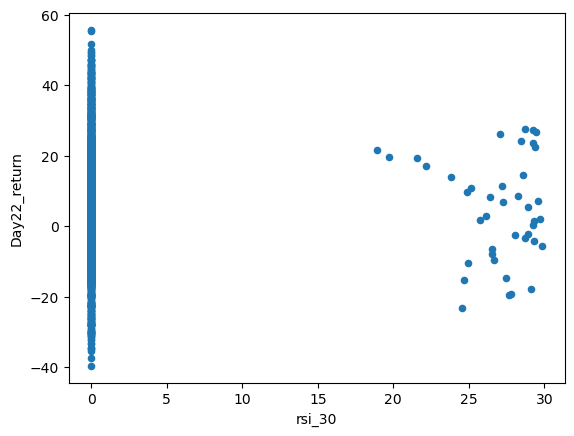

In [1058]:
model_ndf.plot(kind='scatter', x='rsi_30', y='Day22_return')

In [1059]:
lr_rsi30_return = smf.ols('Day22_return ~ rsi_30', data=model_rsi).fit()
lr_rsi30_return.params

Intercept    5.789712
rsi_30      -0.076010
dtype: float64

In [1054]:
lr_rsi30_return.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Day15_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.107
Date:                Mon, 13 Jul 2026   Prob (F-statistic):              0.147
Time:                        20:03:55   Log-Likelihood:                -10996.
No. Observations:                2855   AIC:                         2.200e+04
Df Residuals:                    2853   BIC:                         2.201e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.9321      0.218     18.039      0.000       3.505       4.360
rsi_30        -0.0484      0.033     -1.452      0.147      -0.114       0.017
==============================================================================
Omnibus:                       37.052   Durbin-Watson:                   0.161
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               52.943
Skew:                           0.148   Prob(JB):                     3.19e-12
Kurtosis:                       3.598   Cond. No.                         6.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='RSI', ylabel='Day22_return'>

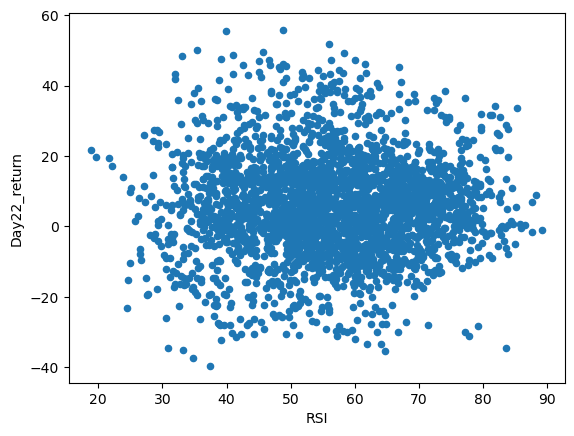

In [1041]:
model_rsi.plot(kind='scatter', x='RSI', y='Day22_return')

In [1042]:
lr_rsi_return = smf.ols('Day22_return ~ RSI', data=model_rsi).fit()
lr_rsi_return.params

Intercept    5.678545
RSI          0.000132
dtype: float64

In [589]:
lr_rsi_return.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Day22_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 3.923e-05
Date:                Mon, 13 Jul 2026   Prob (F-statistic):              0.995
Time:                        00:02:31   Log-Likelihood:                -11598.
No. Observations:                2855   AIC:                         2.320e+04
Df Residuals:                    2853   BIC:                         2.321e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6785      1.218      4.663      0.000       3.291       8.066
RSI            0.0001      0.021      0.006      0.995      -0.041       0.042
==============================================================================
Omnibus:                       43.271   Durbin-Watson:                   0.106
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               56.014
Skew:                           0.207   Prob(JB):                     6.87e-13
Kurtosis:                       3.548   Cond. No.                         267.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [591]:
sorted_rsi = model_rsi.sort_values("RSI")
sorted_rsi

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,bull_haram,rsi_30
Date,,,,,,,,,,,,,,,,,,,
2019-06-03,0,Bearish,-1,43.737075,32.032915,24.230010,18.890754,Bearish,10,20,20,10.950825,8.409355,14.112738,21.654953,63.415461,163.918356,0,1
2019-05-31,0,Bearish,-1,37.668203,60.762298,1.569500,19.708488,Bearish,9,19,19,7.411793,6.776915,12.033068,19.762268,60.353471,162.694767,0,1
2019-05-30,0,Bearish,-1,28.708091,34.449755,36.842153,21.594309,Bearish,8,18,18,3.357054,6.577518,10.775629,19.452261,59.175491,144.605241,0,1
2019-05-29,0,Bearish,1,27.577197,36.340197,36.082606,22.171811,Bearish,7,17,17,0.784708,4.294479,9.231004,17.156525,50.591236,143.832049,0,1
2019-05-28,0,Bearish,1,64.376558,33.587727,2.035715,23.823082,Bearish,6,16,16,-0.116338,5.296905,6.784693,14.014050,46.953346,144.136379,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-06-02,0,Bullish,0,8.511005,42.552997,48.935998,86.491489,Bullish,14,14,14,0.509117,0.869733,2.863795,0.445471,98.476249,207.972212,0,0
2021-11-09,0,Bearish,1,69.266899,1.193515,29.539586,87.533652,Bullish,3,19,20,-1.480895,3.552226,2.550317,-1.485139,-42.590099,-52.331585,0,0
2021-11-05,0,Bearish,1,21.859272,60.954748,17.185980,87.633941,Bullish,1,17,18,2.144377,10.866500,12.180697,6.984059,-37.212755,-52.381871,0,0


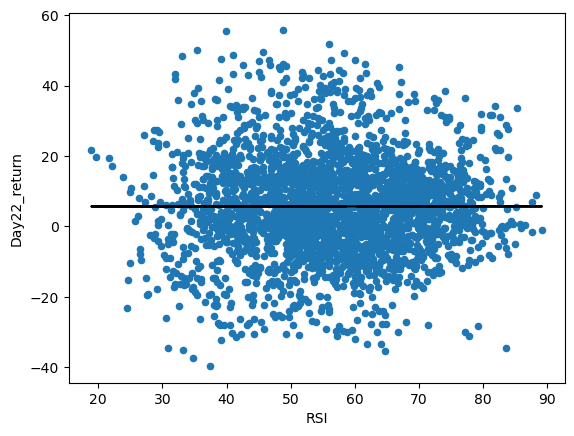

In [597]:
model_rsi.plot(y = 'Day22_return', x = 'RSI', kind ='scatter')
plt.plot(model_rsi['RSI'], lr_rsi_return.fittedvalues, color = 'black');

plt.savefig(
    "rsi_22day_return.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
derby.plot(x = 'year', y = 'speed', kind = 'scatter')
plt.plot(derby['year'], lm.fittedvalues, color = 'black');

In [ ]:
model_ndf.plot(x=

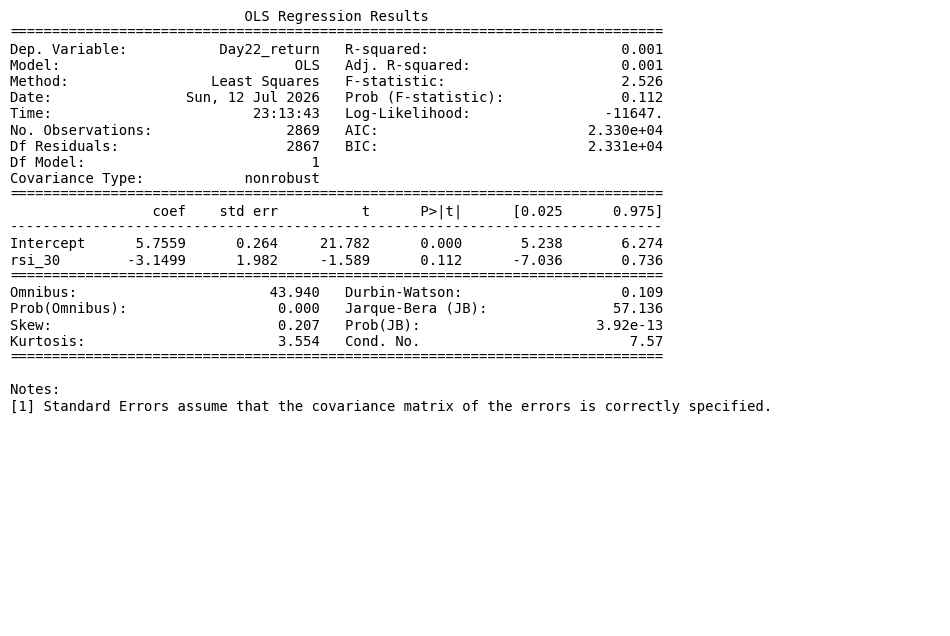

In [559]:
summary_t = lr_rsi_return_day22.summary().as_text()

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

ax.text(
    0,
    1,
    summary_t,
    fontsize=10,
    family='monospace',
    va='top'
)

plt.savefig("rsi_day22_regression_summary.png", dpi=300, bbox_inches='tight')
plt.show()

In [1105]:
model_ndf['bull_haram'] = (model_ndf['Harami'] == 100).astype(int)
model_ndf

,Harami,Bullish/Bearish,confirmed_trend,Body %,Upper_wick_percentage,Lower_wick_percentage,RSI,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,Day5_return,Day10_return,Day15_return,Day22_return,Month6_return,1_year_return,rsi_30,Day22_5%_prof,downtrend,positive_22day_return,bull_haram
Date,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0,Doji,0,0.000000,31.915002,68.084998,NaN,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,0.0,0,0,1,0
2015-01-05,0,Bearish,0,69.387800,12.244977,18.367223,NaN,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,0.0,0,0,1,0
2015-01-06,0,Bearish,0,94.029920,2.985040,2.985040,NaN,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,0.0,1,0,1,0
2015-01-07,0,Bearish,0,45.237879,40.476326,14.285795,NaN,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,0.0,1,0,1,0
2015-01-08,0,Bullish,0,79.364899,19.047727,1.587374,NaN,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,0.0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,0,Bearish,0,13.625776,56.120252,30.253972,37.574160,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0,0
2026-06-29,0,Bullish,0,17.554811,18.965414,63.479775,40.158152,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0,0
2026-06-30,0,Bullish,0,51.630229,9.782756,38.587015,45.276875,divergence,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0,0


In [504]:
model_ndf.groupby("bull_haram")["Day22_return"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
bull_haram,,,,
0,2756,5.693142,5.336089,14.056197
1,113,5.865693,4.655398,13.473395


In [599]:
import seaborn as sns

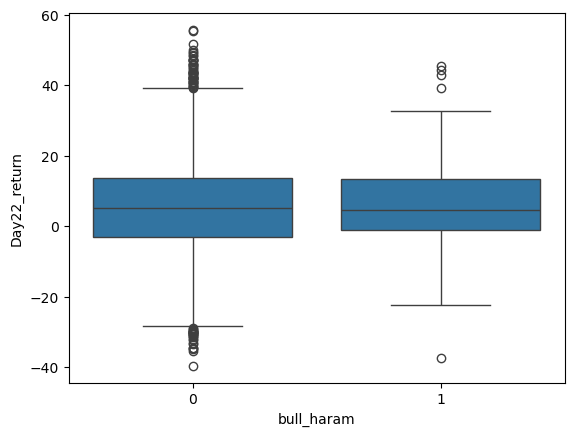

In [605]:
sns.boxplot(data=model_ndf, y='Day22_return', x='bull_haram');

plt.savefig("Harami_22_day_box.png", dpi=300, bbox_inches="tight")

In [570]:
lr_harami_return = smf.ols('Day22_return ~ bull_haram', data=model_ndf).fit()
lr_harami_return.params

Intercept     5.693142
bull_haram    0.172551
dtype: float64

In [571]:
lr_harami_return.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Day22_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.01641
Date:                Sun, 12 Jul 2026   Prob (F-statistic):              0.898
Time:                        23:29:59   Log-Likelihood:                -11648.
No. Observations:                2869   AIC:                         2.330e+04
Df Residuals:                    2867   BIC:                         2.331e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6931      0.267     21.297      0.000       5.169       6.217
bull_haram     0.1726      1.347      0.128      0.898      -2.469       2.814
==============================================================================
Omnibus:                       43.853   Durbin-Watson:                   0.106
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.437
Skew:                           0.204   Prob(JB):                     3.37e-13
Kurtosis:                       3.560   Cond. No.                         5.15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Bullish Harami** days, while having some small effect, seem to be **statistically insignificant** in ALL return results when compared to the "normal" days based on P-values. 

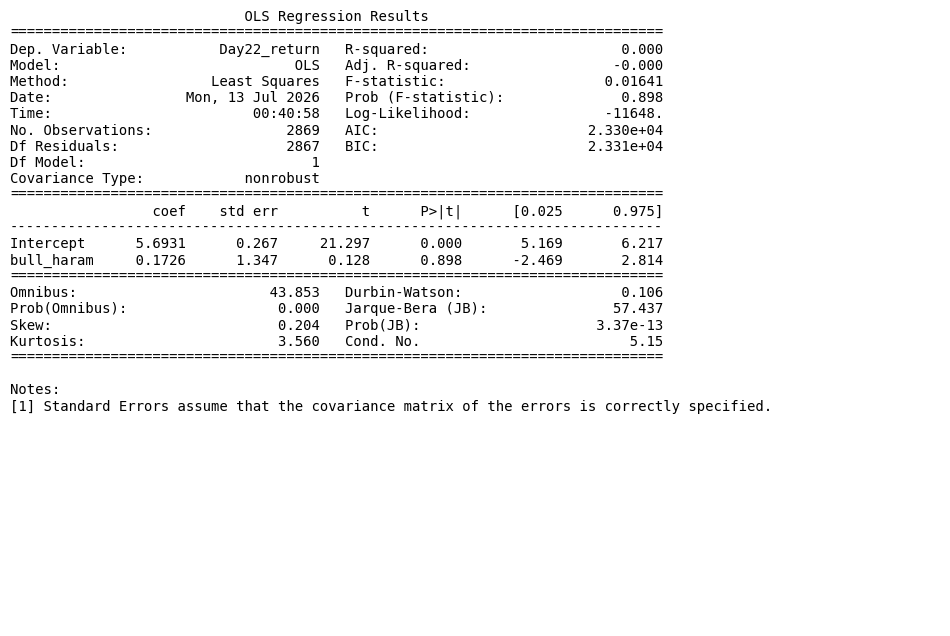

In [603]:
summary_t = lr_harami_return.summary().as_text()

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

ax.text(
    0,
    1,
    summary_t,
    fontsize=10,
    family='monospace',
    va='top'
)

plt.savefig("bull_haram_regression_summary.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
derby.plot(x = 'year', y = 'speed', kind = 'scatter')
plt.plot(derby['year'], lm.fittedvalues, color = 'black');

In [451]:
ndf.columns

Index(['Ticker', 'Close', 'High', 'Low', 'Open', 'Volume', 'Bullish/Bearish',
       'confirmed_trend', 'Harami', 'Harami_cross', 'Body %', 'Upper_wick',
       'Upper_wick_percentage', 'Lower_wick', 'Lower_wick_percentage',
       'Wick_to_body_ratio', 'RSI', 'gap_size', 'gap_percentage', '5_EMA',
       '10_EMA', '20_EMA', '50_EMA', '200_EMA', 'EMA_Alignment',
       '5EMA_touched', '10EMA_touched', '20EMA_touched', '50EMA_touched',
       '200EMA_touched', '5EMA_days_since_touch', '10EMA_days_since_touch',
       '20EMA_days_since_touch', 'Day5_return', 'Day10_return', 'Day15_return',
       'Day22_return', 'Month6_return', '1_year_return', 'Year5_return',
       'Candle_Body', 'Candle_Range', '5_EMA_candle_location',
       '5_EMA_candle_distance', '10_EMA_candle_location',
       '10_EMA_candle_distance', '20_EMA_candle_location',
       '20_EMA_candle_distance', '50_EMA_candle_location',
       '50_EMA_candle_distance', '200_EMA_candle_location',
       '200_EMA_candle_distance',

In [204]:
ndf.groupby("Harami")["10_day_return"].mean()

Harami
-100    0.248652
 0      2.642964
 100    2.271840
Name: 10_day_return, dtype: float64

In [208]:
ndf["positive_22_day_return_num"] = ndf["positive_22_day_return"].astype(int)
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,Close_to_5EMA_pct,Close_to_10EMA_pct,Close_to_20EMA_pct,Close_to_50EMA_pct,Close_to_200EMA_pct,positive_22_day_return,positive_22_day_return_num
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,0.000000,0.000000,0.000000,0.000000,0.000000,True,1
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,-1.132399,-1.386195,-1.530637,-1.623874,-1.672510,True,1
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,-2.791686,-3.609065,-4.103596,-4.433820,-4.609447,True,1
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,-2.050791,-3.180680,-3.955240,-4.507457,-4.811977,True,1
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,1.083305,0.377204,-0.309785,-0.879696,-1.219146,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,-2.791197,-4.601334,-6.389526,-6.293747,2.076161,False,0
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,-1.044921,-2.792753,-4.731071,-4.915776,3.335160,False,0
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,1,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.213841,2.270004e+00,1.164284,198.049196,200.483927,204.217745,204.855287,188.790870,divergence,True,True,False,False,False,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.849991,5.520004,1.030451,-0.196490,-2.021249,-2.326174,5.984996,False,0


For this I need to do more than just the feature. I need to do the feature being bought at a certain point 

In [232]:
ndf.to_csv('NVDA.csv', index=True, index_label='Date')

In [ ]:
#number of rows(days) to hold each trade


hold_period = 12


entries_10 =(ema_10_fix &
    (ndf['10_EMA_candle_location'] == 'Above')
            ).fillna(False).astype(bool)

#copy our variable filter in case something goes wrong 
entries_10 = entries_10.copy()
entries_10.iloc[-hold_period:] = False

@njit 

#Polakow, O. VectorBT: Signals Factory. GitHub repository, vectorbt/signals/factory.py, wait_choice_nb example. Accessed July 10, 2026
#fixed-period exit function adatped from VectorBT's official wait_choice_nb signal generation example.
def fixed_hold_exit_nb(from_i, to_i, col, hold_period, temp_idx_arr):

    exit_position = from_i + hold_period - 1 

    if exit_position < to_i:
        temp_idx_arr[0] = exit_position
        return temp_idx_arr[:1]
        
    return temp_idx_arr[:0] 

#fixed holding period generator also from VectorBTs signal generato example 

fixedholdsignals = SignalFactory(mode='chain',
                               param_names=['hold_period']
                              ).from_choice_func(exit_choice_func=fixed_hold_exit_nb,
                                                 exit_settings={
                                                     "pass_params": ['hold_period'],
                                                     'pass_kwargs':['temp_idx_arr']
                                                 }
                                                )

#Generate entries and exits 
signals_10 = fixedholdsignals.run(
    entries_10, hold_period

    
# exclude new entries while another trade was going 
long_entries_10 = signals_10.new_entries.squeeze()
long_exits_10 = signals_10.exits.squeeze()
